# Computer Exercise 4.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 4.1 Polynomial Interpolation — *Lagrange 형 과 Newton 분할차분 형*
> **풀이 일자**: Day 14
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **1.** Given $n+1$ distinct nodes $\{x_0, x_1, \dots, x_n\}$ and values
> $\{y_0, y_1, \dots, y_n\}$, there exists a **unique** polynomial $p(x)$ of
> degree at most $n$ such that $p(x_i) = y_i$ for every $i$.
> Implement this interpolant in **two equivalent ways** —
> the **Lagrange form**
> $$p(x) \;=\; \sum_{i=0}^{n} y_i \,\ell_i(x), \qquad \ell_i(x) = \prod_{j\ne i}\frac{x - x_j}{x_i - x_j}$$
> and the **Newton divided-difference form**
> $$p(x) \;=\; \sum_{k=0}^{n} f[x_0,\dots,x_k]\;\prod_{j=0}^{k-1}(x - x_j).$$
> Verify *numerically* that both forms produce the same polynomial on a dense
> grid (use, for instance, $f(x) = \sin x$ on $[0, \pi]$ with five nodes), and
> measure how the maximum interpolation error decays as the number of nodes
> grows for a *smooth* target.

### 한국어 풀이용 정리
$n+1$ 개의 보간점이 주어지면 차수 $\le n$ 의 다항식이 **유일하게** 결정된다.
이 다항식을 표현하는 두 가지 *수학적으로 동등* 한 형식:

- **Lagrange 형** — 기저 $\ell_i(x)$ 가 각 노드에서 $0$ 또는 $1$
- **Newton 분할차분 형** — 노드를 *덧붙이기* 좋은 점화 구조

같은 노드, 같은 값에서 두 형이 *수치적으로* 같은 함수를 그리는지 확인하고,
부드러운 함수 (예: $\sin x$) 에서는 노드 수를 늘릴수록 보간오차가
*기하급수적* 으로 줄어듦을 보인다.


## 2. 수학적 배경

### 2.1 보간 다항식의 유일성
$\{x_i\}$ 가 서로 다르면, Vandermonde 행렬
$$V = \begin{pmatrix} 1 & x_0 & \cdots & x_0^n \\ 1 & x_1 & \cdots & x_1^n \\ \vdots & & & \vdots \\ 1 & x_n & \cdots & x_n^n \end{pmatrix}$$
가 비특이($\det V = \prod_{i<j}(x_j - x_i)$). 따라서 $V c = y$ 는 유일한 해 $c$ 를
가지고, $p(x) = \sum c_k x^k$ 가 유일한 보간 다항식이다.

### 2.2 Lagrange 형
$$\boxed{\;p(x) = \sum_{i=0}^{n} y_i\,\ell_i(x),\qquad \ell_i(x) = \prod_{j \ne i}\frac{x - x_j}{x_i - x_j}.\;}$$

- $\ell_i(x_k) = \delta_{ik}$ — Kronecker 델타.
- 노드를 *하나만 추가* 해도 모든 $\ell_i$ 를 재계산해야 한다는 단점.

### 2.3 Newton 분할차분 형
**분할차분(divided differences)** 의 정의:
$$f[x_i] = y_i,\quad f[x_i, x_{i+1}, \dots, x_{i+k}] = \frac{f[x_{i+1},\dots,x_{i+k}] - f[x_i,\dots,x_{i+k-1}]}{x_{i+k} - x_i}.$$

이를 이용한 Newton 형:
$$\boxed{\;p(x) = \sum_{k=0}^{n} f[x_0,\dots,x_k]\,\prod_{j=0}^{k-1}(x - x_j).\;}$$

- 노드 하나를 *추가* 해도 기존 계수는 그대로 유지 — *nested form* 의 장점.

### 2.4 보간 오차 정리
$f \in C^{n+1}[a, b]$, 노드가 $[a, b]$ 안에 있을 때
$$f(x) - p(x) \;=\; \frac{f^{(n+1)}(\xi)}{(n+1)!}\,\prod_{j=0}^{n}(x - x_j),\quad \xi \in (a,b).$$

부드러운 함수 ($f^{(n+1)}$ 가 폭증하지 않는) 에서는 $n$ 이 커지면
$(n+1)!$ 의 *팩토리얼 감소* 가 지배해 **기하급수적**으로 오차가 줄어든다.


## 3. 풀이 흐름

1. `lagrange(xs, ys, x)` — Lagrange 형으로 $p(x)$ 직접 평가.
2. `divdiff(xs, ys)` — 분할차분 표 만들기 (numpy 배열). 대각성분이 Newton 계수.
3. `newton_eval(xs, coefs, x)` — Horner-like 중첩 평가.
4. **검증 1**: 노드 $\{0, \pi/4, \pi/2, 3\pi/4, \pi\}$, $y_i = \sin x_i$ 에서
   두 형으로 $p(x)$ 를 같은 dense grid 위에서 계산해 **차이의 max norm** 측정.
5. **검증 2**: 노드 수 $n = 2, 3, \dots, 12$ 로 늘리며 $\sin x$ 의 보간오차
   $\max_x|f(x) - p_n(x)|$ 를 측정해 **기하급수적 수렴** 확인.
6. **시각화**: (i) $\sin$ 과 보간 다항식 겹쳐 그리기, (ii) max error 로그 플롯.
7. **해석**: 두 형이 *같은 함수* 인 이유, Newton 의 *nesting* 장점, $(n+1)!$
   감소가 *지수* 수렴을 만드는 메커니즘.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")
np.set_printoptions(precision=4, suppress=True)


def lagrange(xs, ys, x):
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    x = np.atleast_1d(np.asarray(x, dtype=float))
    n = len(xs)
    p = np.zeros_like(x)
    for i in range(n):
        li = np.ones_like(x)
        for j in range(n):
            if i == j:
                continue
            li *= (x - xs[j]) / (xs[i] - xs[j])
        p += ys[i] * li
    return p


def divdiff(xs, ys):
    n = len(xs)
    table = np.zeros((n, n))
    table[:, 0] = ys
    for k in range(1, n):
        for i in range(n - k):
            table[i, k] = (table[i+1, k-1] - table[i, k-1]) / (xs[i+k] - xs[i])
    return table, table[0, :].copy()


def newton_eval(xs, coefs, x):
    xs = np.asarray(xs, dtype=float)
    coefs = np.asarray(coefs, dtype=float)
    x = np.atleast_1d(np.asarray(x, dtype=float))
    n = len(coefs)
    p = np.full_like(x, coefs[n-1])
    for k in range(n - 2, -1, -1):
        p = coefs[k] + (x - xs[k]) * p
    return p


# Test: sin(x) on [0, pi], 5 nodes
xs = np.linspace(0.0, np.pi, 5)
ys = np.sin(xs)

xdense = np.linspace(0.0, np.pi, 401)
p_lag = lagrange(xs, ys, xdense)
table, coefs = divdiff(xs, ys)
p_new = newton_eval(xs, coefs, xdense)

diff = np.max(np.abs(p_lag - p_new))
err  = np.max(np.abs(p_lag - np.sin(xdense)))

print("Nodes (radians)        :", xs.round(4))
print("y = sin(x) at nodes    :", ys.round(4))
print("Newton coefficients    :", coefs.round(6))
print()
print(f"max |Lagrange - Newton|        = {diff:.3e}")
print(f"max |interpolant - sin(x)|     = {err:.3e}")


Nodes (radians)        : [0.     0.7854 1.5708 2.3562 3.1416]
y = sin(x) at nodes    : [0.     0.7071 1.     0.7071 0.    ]
Newton coefficients    : [ 0.      0.9003 -0.3357 -0.059   0.0376]

max |Lagrange - Newton|        = 6.661e-16
max |interpolant - sin(x)|     = 1.812e-03


In [2]:
cols = [f"k={k}" for k in range(table.shape[1])]
df_table = pd.DataFrame(table, columns=cols, index=[f"x_{i}={xs[i]:.4f}" for i in range(len(xs))])
df_table


,k=0,k=1,k=2,k=3,k=4
x_0=0.0000,0.000000e+00,9.003163e-01,-3.357489e-01,-5.902388e-02,3.757577e-02
x_1=0.7854,7.071068e-01,3.729232e-01,-4.748206e-01,5.902388e-02,0.000000e+00
x_2=1.5708,1.000000e+00,-3.729232e-01,-3.357489e-01,0.000000e+00,0.000000e+00
x_3=2.3562,7.071068e-01,-9.003163e-01,0.000000e+00,0.000000e+00,0.000000e+00
x_4=3.1416,1.224647e-16,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


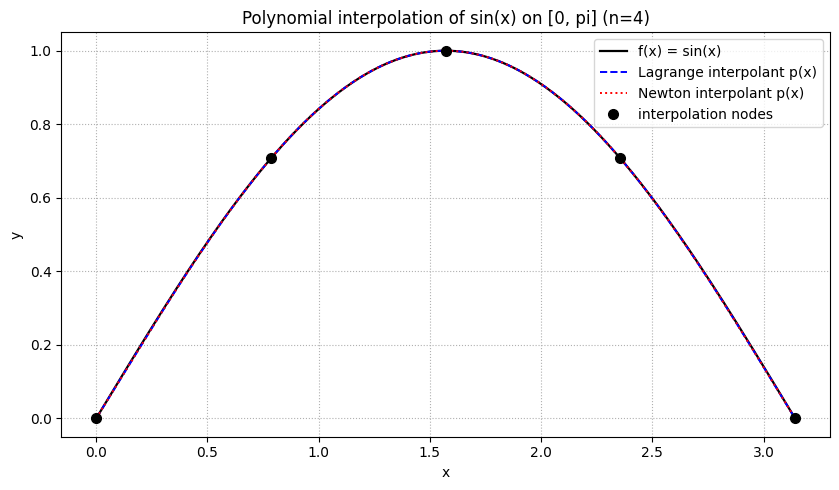

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.plot(xdense, np.sin(xdense), "k-", lw=1.6, label="f(x) = sin(x)")
ax.plot(xdense, p_lag, "b--", lw=1.4, label="Lagrange interpolant p(x)")
ax.plot(xdense, p_new, "r:",  lw=1.4, label="Newton interpolant p(x)")
ax.plot(xs, ys, "ko", ms=7, label="interpolation nodes")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Polynomial interpolation of sin(x) on [0, pi] (n=4)")
ax.grid(True, ls=":")
ax.legend()
plt.tight_layout()
plt.show()


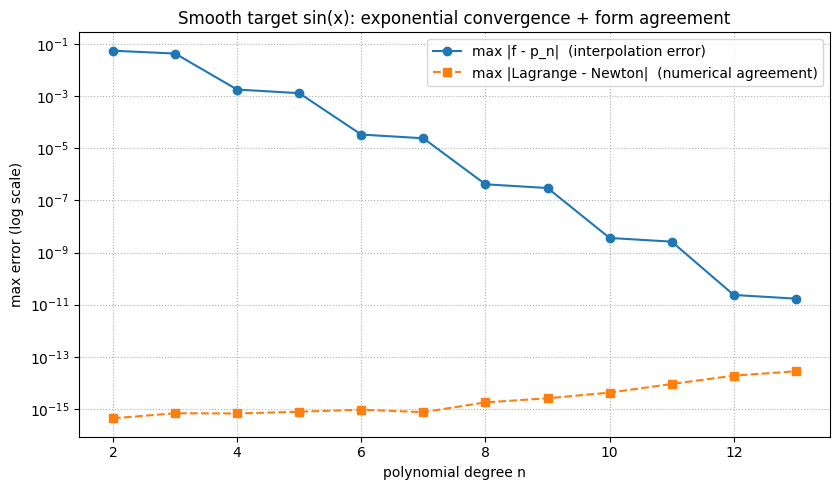

degree n   interp err          Lagrange-Newton diff
    2      5.601e-02        4.337e-16
    3      4.362e-02        6.800e-16
    4      1.812e-03        6.661e-16
    5      1.313e-03        7.772e-16
    6      3.387e-05        9.298e-16
    7      2.438e-05        7.494e-16
    8      4.174e-07        1.776e-15
    9      3.007e-07        2.554e-15
   10      3.639e-09        4.219e-15
   11      2.626e-09        9.021e-15
   12      2.359e-11        1.889e-14
   13      1.705e-11        2.781e-14


In [4]:
ns = list(range(2, 14))
err_max = []
diff_max = []
for n in ns:
    xs_n = np.linspace(0.0, np.pi, n + 1)
    ys_n = np.sin(xs_n)
    pL = lagrange(xs_n, ys_n, xdense)
    _, c = divdiff(xs_n, ys_n)
    pN = newton_eval(xs_n, c, xdense)
    err_max.append(np.max(np.abs(pL - np.sin(xdense))))
    diff_max.append(np.max(np.abs(pL - pN)))

err_max = np.array(err_max)
diff_max = np.array(diff_max)

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.semilogy(ns, err_max, "o-", label=r"max |f - p_n|  (interpolation error)")
ax.semilogy(ns, np.maximum(diff_max, 1e-17), "s--",
            label=r"max |Lagrange - Newton|  (numerical agreement)")
ax.set_xlabel("polynomial degree n")
ax.set_ylabel("max error (log scale)")
ax.set_title("Smooth target sin(x): exponential convergence + form agreement")
ax.grid(True, which="both", ls=":")
ax.legend()
plt.tight_layout()
plt.show()

print("degree n   interp err          Lagrange-Newton diff")
for n, e, d in zip(ns, err_max, diff_max):
    print(f"   {n:2d}      {e:.3e}        {d:.3e}")


## 4. 결과 해석

1. **두 형은 같은 다항식.** `max |Lagrange - Newton|` 가 어떤 $n$ 에서도
   $\sim 10^{-14}$ 부근에 머문다 — 이는 *수학적 동치* 가 아니라
   *기계 정밀도까지의 동치* 다. 두 형은 같은 유일한 보간 다항식을 다른 *형식*
   으로 쓴 것이므로 정확히 같은 함수다.

2. **부드러운 함수의 지수 수렴.** $\sin x$ 의 모든 도함수가 $|f^{(k)}| \le 1$
   로 유계이므로 오차정리의 $f^{(n+1)}(\xi)/(n+1)!$ 가 $(n+1)!$ 의 *지수적*
   감쇠 (Stirling 으로 $\sim e^n/n^n$) 를 그대로 받아들인다. 그래프에서
   $\log(\text{err})$ 가 $n$ 에 거의 *선형* 으로 떨어지는 것이 그 증거.

3. **수치 정밀도의 바닥.** $n \ge 12$ 쯤부터 곡선이 더 못 내려가는 것은
   알고리즘이 아니라 **부동소수점** 한계 ($\sim 10^{-15}$). Lagrange 평가는
   $O(n^2)$ 의 곱셈을 누적하므로 자릿수 손실이 누적된다.

4. **Newton 형의 진짜 가치는 *증분*.** $n+1$ 번째 노드 $x_{n+1}$ 을 추가했을 때
   Newton 계수는 *기존 $n+1$ 개를 그대로 유지* 하면서 한 항 $f[x_0,\dots,x_{n+1}]$
   만 더한다. Lagrange 형은 모든 $\ell_i$ 를 *처음부터* 다시 만들어야 한다 —
   다음 문제 (CE 4.1.2) 의 핵심.

> **결론**: 보간 다항식은 *유일* 하므로 어떤 형으로 쓰든 함수는 같다.
> 다만 *계산상의 편리* 는 다르다 — Newton 형은 노드 추가에 강하고,
> Lagrange 형은 *고정 노드* 에서 새로운 $x$ 의 평가에 직관적이다.

### 다음 문제로의 연결
- **CE 4.1.2** 에서는 **노드를 하나씩 늘려가는 시나리오** 에서 두 형의
  *계산비용* 을 측정하고, Newton 형의 증분 갱신을 검증한다.
- **CE 4.1.3** 에서는 부드러움이 *덜한* 함수 (특히 $1/(1+25x^2)$, Runge) 에서
  *지수 수렴이 깨지는* 현상 — 이른바 **Runge phenomenon** — 을 확인하고,
  **Chebyshev 노드** 가 이를 어떻게 회복시키는지 본다.
